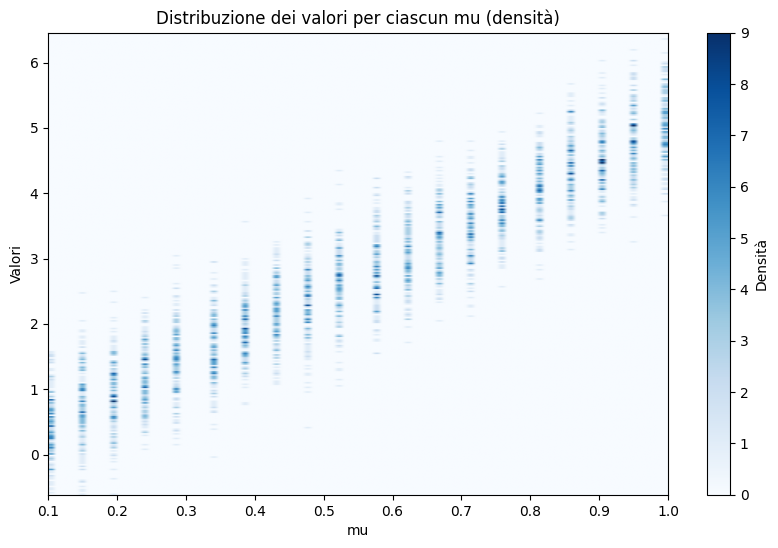

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Esempio di valori di mu
mu_values = np.linspace(0.1, 1.0, 20)

# Generiamo valori per ciascun mu (es: distribuzioni gaussiane centrate su mu*5)
data_x = []
data_y = []

for mu in mu_values:
    y_vals = np.random.normal(loc=mu * 5, scale=0.5, size=200)
    x_vals = np.full_like(y_vals, mu)
    data_x.extend(x_vals)
    data_y.extend(y_vals)

# Costruzione della griglia bidimensionale
x_bins = np.linspace(min(mu_values), max(mu_values), 100)
y_bins = np.linspace(min(data_y), max(data_y), 300)

H, xedges, yedges = np.histogram2d(data_x, data_y, bins=[x_bins, y_bins])

# Transponi per poterlo plottare correttamente (imshow richiede trasposizione)
H = H.T

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(H, aspect='auto', origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           cmap='Blues')  # o 'viridis', 'plasma' ecc.

plt.xlabel('mu')
plt.ylabel('Valori')
plt.title('Distribuzione dei valori per ciascun mu (densità)')
plt.colorbar(label='Densità')
plt.show()


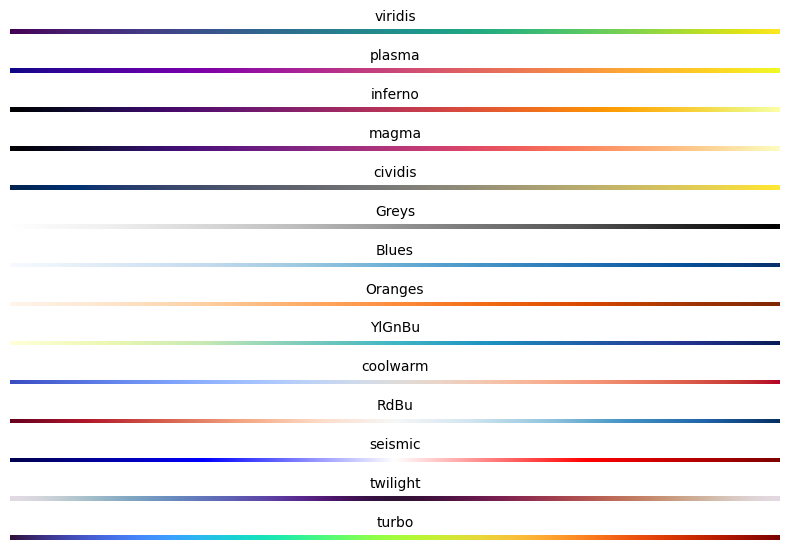

In [1]:
import matplotlib.pyplot as plt

import numpy as np

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))

colormaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis',
             'Greys', 'Blues', 'Oranges', 'YlGnBu',
             'coolwarm', 'RdBu', 'seismic', 'twilight', 'turbo']

fig, axes = plt.subplots(nrows=len(colormaps), figsize=(8, len(colormaps)*0.4))
for ax, cmap in zip(axes, colormaps):
    ax.imshow(gradient, aspect='auto', cmap=cmap)
    ax.set_title(cmap, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# KDE

In [10]:
import numpy as np
from scipy import stats
def measure(n):
    "Measurement model, return two coupled measurements."
    m1 = np.random.normal(size=n)
    m2 = np.random.normal(scale=0.2, size=n)
    return m1+m2, m1-m2

In [11]:
m1, m2 = measure(2000)
xmin = m1.min()
xmax = m1.max()
ymin = m2.min()
ymax = m2.max()

In [12]:
X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([m1, m2])
kernel = stats.gaussian_kde(values)
Z = np.reshape(kernel(positions).T, X.shape)

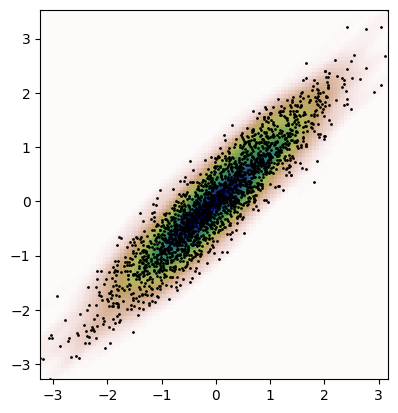

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
          extent=[xmin, xmax, ymin, ymax])
ax.plot(m1, m2, 'k.', markersize=2)
ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, ymax])
plt.show()

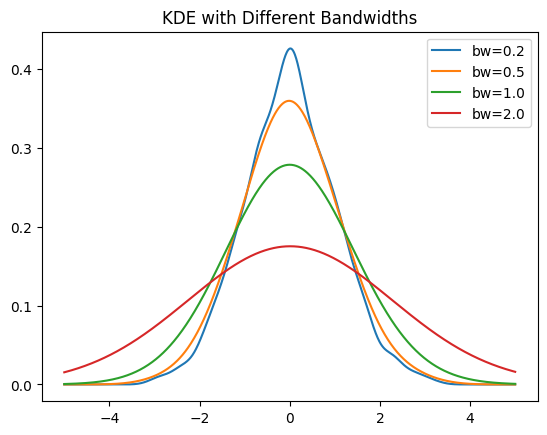

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

data = np.random.normal(0, 1, size=1000)
x_vals = np.linspace(-5, 5, 1000)

# Try different smoothness
for bw in [0.2, 0.5, 1.0, 2.0]:
    kde = gaussian_kde(data, bw_method=bw)
    plt.plot(x_vals, kde(x_vals), label=f'bw={bw}')

plt.legend()
plt.title("KDE with Different Bandwidths")
plt.show()